<a href="https://colab.research.google.com/github/lotfy2233/Customer-Return-ML-Project/blob/main/Customer_Return_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Analysis
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

#process
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('/content/apple_global_sales_dataset.csv')
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [3]:
df.shape

(11500, 27)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

In [5]:
df.isnull().sum()

,0
sale_id,0
sale_date,0
year,0
quarter,0
month,0
country,0
region,0
city,0
product_name,0
category,0


In [6]:
df['return_status'].value_counts()

,count
return_status,
Kept,10143
Returned,898
Exchanged,459


In [7]:
df = df.dropna(subset=['return_status'])

###نشيل:

sale_id → رقم تعريفي

sale_date → ممكن نرجعله بعدين

revenue_local_currency → عندنا revenue_usd

fx_rate_to_usd → مش مهم للتنبؤ بالـ return

year / quarter / month → غالبًا مش سبب مباشر للإرجاع:
###عشان:

نقلل Noise

نقلل Dimensionality

نمنع Data Leakage

In [8]:
df = df.drop([
    'sale_id',
    'sale_date',
    'year',
    'quarter',
    'month',
    'fx_rate_to_usd',
    'revenue_local_currency'
], axis=1)

###منتجات ليها storage (iPhone, iPad)

منتجات ملهاش storage (AirPods, Cable)

الحل الصح:

In [9]:
df['storage'] = df['storage'].fillna('No Storage')

In [10]:
df = df.drop('previous_device_os', axis=1)

ليه mean؟
لأنه Numerical Feature

In [11]:
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].mean())

ليه mode؟
لأنهم Categorical

In [12]:
df['payment_method'].fillna(df['payment_method'].mode()[0], inplace=True)
df['customer_segment'].fillna(df['customer_segment'].mode()[0], inplace=True)
df['customer_age_group'].fillna(df['customer_age_group'].mode()[0], inplace=True)

In [13]:
df.isnull().sum()

,0
country,0
region,0
city,0
product_name,0
category,0
storage,0
color,0
unit_price_usd,0
discount_pct,0
units_sold,0


In [14]:
df['product_name'].nunique()

43

In [15]:
df['product_name'].nunique()
df['city'].nunique()

514

In [16]:
df['city'].nunique()

514

حذف city

ليه؟
لأن عندك:

country

region

ودي كفاية تمثل الموقع الجغرافي.

In [17]:
df = df.drop('city', axis=1)

In [18]:
df = df.drop('currency', axis=1)

In [19]:
df.shape

(11500, 17)

In [20]:
df.columns

Index(['country', 'region', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'customer_rating', 'return_status'],
      dtype='object')

In [21]:
X = df.drop("return_status", axis=1)
y = df["return_status"]

In [22]:
le = LabelEncoder()
y = le.fit_transform(y)
le.classes_

array(['Exchanged', 'Kept', 'Returned'], dtype=object)

In [23]:
y[:10]
le.classes_

array(['Exchanged', 'Kept', 'Returned'], dtype=object)

In [24]:
X = pd.get_dummies(X, drop_first=True)

In [25]:
X = pd.get_dummies(X, drop_first=True)
X.shape

(11500, 153)

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=43)

In [27]:
X_train.shape
X_test.shape

(2300, 153)

In [28]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [31]:
print("Train Accuracy:", lr.score(X_train, y_train))
print("Test Accuracy:", lr.score(X_test, y_test))

Train Accuracy: 0.878804347826087
Test Accuracy: 0.8947826086956522


In [32]:
y_pred = lr.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.89      1.00      0.94      2058
           2       0.00      0.00      0.00       155

    accuracy                           0.89      2300
   macro avg       0.30      0.33      0.31      2300
weighted avg       0.80      0.89      0.85      2300

[[   0   87    0]
 [   0 2058    0]
 [   0  155    0]]


In [33]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced')
lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [34]:
class_weights = 'balanced'

In [35]:
# تدريب
lr.fit(X_train, y_train)

# توقع
y_pred = lr.predict(X_test)

# طباعة النتائج
print("Train Accuracy:", lr.score(X_train, y_train))
print("Test Accuracy:", lr.score(X_test, y_test))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train Accuracy: 0.36293478260869566
Test Accuracy: 0.31521739130434784

Classification Report:

              precision    recall  f1-score   support

           0       0.03      0.31      0.06        87
           1       0.88      0.31      0.46      2058
           2       0.07      0.33      0.11       155

    accuracy                           0.32      2300
   macro avg       0.33      0.32      0.21      2300
weighted avg       0.79      0.32      0.42      2300


Confusion Matrix:

[[ 27  36  24]
 [740 647 671]
 [ 50  54  51]]


In [36]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy:", rf.score(X_test, y_test))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.8947826086956522

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.89      1.00      0.94      2058
           2       0.00      0.00      0.00       155

    accuracy                           0.89      2300
   macro avg       0.30      0.33      0.31      2300
weighted avg       0.80      0.89      0.85      2300


Confusion Matrix:

[[   0   87    0]
 [   0 2058    0]
 [   0  155    0]]


In [37]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# موازنة البيانات
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

# تدريب النموذج
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

# التوقع
y_pred = rf.predict(X_test)

print("Train Accuracy:", rf.score(X_train_res, y_train_res))
print("Test Accuracy:", rf.score(X_test, y_test))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.8947826086956522

Classification Report:

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.89      1.00      0.94      2058
           2       0.00      0.00      0.00       155

    accuracy                           0.89      2300
   macro avg       0.30      0.33      0.31      2300
weighted avg       0.80      0.89      0.85      2300


Confusion Matrix:

[[   0   87    0]
 [   0 2058    0]
 [   0  155    0]]


In [38]:
import pandas as pd

print("Training target distribution:")
print(pd.Series(y_train).value_counts())

print("\nTest target distribution:")
print(pd.Series(y_test).value_counts())

Training target distribution:
1    8085
2     743
0     372
Name: count, dtype: int64

Test target distribution:
1    2058
2     155
0      87
Name: count, dtype: int64


In [39]:
print("After SMOTE:")
print(pd.Series(y_train_res).value_counts())

After SMOTE:
1    8085
2    8085
0    8085
Name: count, dtype: int64


In [40]:
import numpy as np

probs = rf.predict_proba(X_test)

print("Example probabilities:")
print(probs[:10])

print("\nUnique predicted classes:")
print(np.unique(rf.predict(X_test)))

Example probabilities:
[[0.01  0.92  0.07 ]
 [0.065 0.86  0.075]
 [0.05  0.87  0.08 ]
 [0.03  0.925 0.045]
 [0.09  0.815 0.095]
 [0.105 0.715 0.18 ]
 [0.055 0.87  0.075]
 [0.035 0.84  0.125]
 [0.05  0.79  0.16 ]
 [0.04  0.835 0.125]]

Unique predicted classes:
[1]


In [41]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix

gb = GradientBoostingClassifier()

gb.fit(X_train_res, y_train_res)

y_pred = gb.predict(X_test)

print("Test Accuracy:", gb.score(X_test, y_test))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Test Accuracy: 0.8947826086956522
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        87
           1       0.89      1.00      0.94      2058
           2       0.00      0.00      0.00       155

    accuracy                           0.89      2300
   macro avg       0.30      0.33      0.31      2300
weighted avg       0.80      0.89      0.85      2300

[[   0   87    0]
 [   0 2058    0]
 [   0  155    0]]


In [42]:
import numpy as np

probs = rf.predict_proba(X_test)

y_pred_custom = []

for p in probs:
    if p[2] > 0.15:
        y_pred_custom.append(2)
    elif p[0] > 0.15:
        y_pred_custom.append(0)
    else:
        y_pred_custom.append(1)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_custom))
print(confusion_matrix(y_test, y_pred_custom))

              precision    recall  f1-score   support

           0       0.08      0.05      0.06        87
           1       0.89      0.82      0.85      2058
           2       0.06      0.13      0.08       155

    accuracy                           0.75      2300
   macro avg       0.34      0.33      0.33      2300
weighted avg       0.80      0.75      0.77      2300

[[   4   73   10]
 [  47 1690  321]
 [   0  135   20]]


In [43]:
print(X.shape)

(11500, 153)


In [44]:
import numpy as np
print("Number of features:", X.shape[1])

Number of features: 153


In [45]:
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=30)

X_train_sel = selector.fit_transform(X_train_res, y_train_res)
X_test_sel = selector.transform(X_test)

rf = RandomForestClassifier(n_estimators=300, random_state=42)

rf.fit(X_train_sel, y_train_res)

y_pred = rf.predict(X_test_sel)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.09      0.03      0.05        87
           1       0.90      0.96      0.93      2058
           2       0.06      0.02      0.03       155

    accuracy                           0.87      2300
   macro avg       0.35      0.34      0.34      2300
weighted avg       0.81      0.87      0.83      2300

[[   3   82    2]
 [  30 1985   43]
 [   2  150    3]]


In [46]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

xgb = XGBClassifier(
    n_estimators=400,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb.fit(X_train_sel, y_train_res)

y_pred = xgb.predict(X_test_sel)

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.01      0.02        87
           1       0.90      1.00      0.94      2058
           2       0.00      0.00      0.00       155

    accuracy                           0.89      2300
   macro avg       0.47      0.34      0.32      2300
weighted avg       0.82      0.89      0.85      2300

[[   1   86    0]
 [   1 2056    1]
 [   0  155    0]]


x147    0.072249
x150    0.060458
x149    0.053718
x139    0.053259
x1      0.050919
x136    0.050385
x142    0.048264
x2      0.042179
x74     0.037816
x87     0.033439
x86     0.032745
x45     0.032504
x40     0.031706
x95     0.031578
x43     0.031577
x11     0.031375
x24     0.028258
x85     0.027234
x93     0.025835
x92     0.025010
dtype: float32


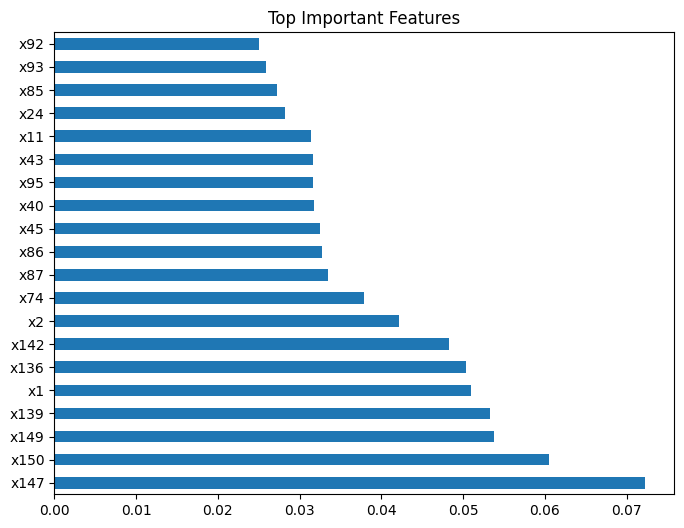

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

importance = xgb.feature_importances_

feature_names = selector.get_feature_names_out()

feat_imp = pd.Series(importance, index=feature_names)

feat_imp = feat_imp.sort_values(ascending=False)

print(feat_imp.head(20))

feat_imp.head(20).plot(kind='barh', figsize=(8,6))
plt.title("Top Important Features")
plt.show()

In [48]:
y_train_binary = (y_train_res != 1).astype(int)
y_test_binary = (y_test != 1).astype(int)

from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=300, random_state=42)

xgb.fit(X_train_sel, y_train_binary)

y_pred = xgb.predict(X_test_sel)

from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test_binary, y_pred))
print(confusion_matrix(y_test_binary, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.98      0.93      2058
           1       0.08      0.02      0.03       242

    accuracy                           0.88      2300
   macro avg       0.49      0.50      0.48      2300
weighted avg       0.81      0.88      0.84      2300

[[2012   46]
 [ 238    4]]


In [49]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

iso = IsolationForest(contamination=0.1, random_state=42)

iso.fit(X_train_sel)

pred = iso.predict(X_test_sel)

pred = [1 if x == -1 else 0 for x in pred]

print(classification_report(y_test_binary, pred))
print(confusion_matrix(y_test_binary, pred))

              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2058
           1       0.12      0.16      0.13       242

    accuracy                           0.79      2300
   macro avg       0.51      0.51      0.51      2300
weighted avg       0.81      0.79      0.80      2300

[[1770  288]
 [ 204   38]]


In [50]:
IsolationForest(contamination=0.15)

IsolationForest(contamination=0.15)

#Customer Return Risk Detection using Machine Learning

#### Customer Return Risk Detection using Machine Learning

This project analyzes customer purchase transactions and predicts the likelihood of product returns using machine learning techniques.

The dataset contains 11,500 transactions with 153 features describing customer behavior, product attributes, and transaction details.

The objective is to identify risky transactions that may result in product returns or exchanges.

Several machine learning models were implemented and evaluated to understand how well they can detect rare events in an imbalanced dataset.

The project demonstrates the importance of handling class imbalance and choosing the correct modeling approach.


##Dataset Overview
Feature	Description
Rows	11,500
Columns	153
Target	return_status
Classes	Kept / Returned / Exchanged

Normal Purchase

Risk Transaction

##Exploratory Data Analysis
Exploratory Data Analysis (EDA) was performed to understand the structure of the dataset.

Key observations:

• The dataset contains significant class imbalance.
• Most transactions were normal purchases.
• Returned and exchanged transactions represent a small minority of the data.
• Feature importance analysis showed that only a limited number of features contributed significantly to predictions.

These findings influenced the modeling approach used later in the project.


##Data Preprocessing
The following preprocessing steps were applied before model training:

• Handling missing values
• Encoding categorical variables
• Feature scaling using StandardScaler
• Feature selection using SelectKBest
• Addressing class imbalance using SMOTE
• Transforming the problem into binary classification

These steps helped prepare the dataset for machine learning algorithms.


##Machine Learning Models Used

Model	Purpose

Logistic Regression	Baseline model

Random Forest	Ensemble learning

Gradient Boosting	Boosted decision
trees

XGBoost	Advanced boosting model

Isolation Forest	Anomaly detection

##Model Evaluation
Accuracy

Precision

Recall

F1 Score

Confusion Matrix

##Key Findings
The dataset presented a significant class imbalance problem, which caused traditional classification models to favor the majority class.

Despite trying multiple algorithms such as Random Forest and XGBoost, the models struggled to detect rare return events.

Reframing the problem as an anomaly detection task using Isolation Forest improved the ability to identify unusual transactions.

This highlights the importance of selecting the correct modeling approach for imbalanced datasets.


##📊 Results
Model	Performance

Logistic Regression	Poor detection of
rare cases

Random Forest	High accuracy but ignored minority classes

XGBoost	Similar behavior

Isolation Forest	Improved detection of risky transactions

##🛠 Tools Used
Tool	Purpose

Python	Programming

Pandas	Data analysis

NumPy	Numerical computing

Matplotlib	Visualization

Seaborn	Data visualization

Scikit-learn	Machine learning

##🚀 Future Improvements
Future improvements for this project include:

• Collecting more balanced data

• Performing additional feature engineering

• Hyperparameter tuning

• Testing deep learning models

• Using advanced anomaly detection techniques
